In [23]:
import os
def walk_dir(path):
    for dirpth, dirnames, names in os.walk(path):
        print(f"there be {len(dirnames)} dirs n {len(names)} images in the {dirpth}")

In [24]:
walk_dir('data/pizza_steak_sushi')

there be 2 dirs n 0 images in the data/pizza_steak_sushi
there be 3 dirs n 0 images in the data/pizza_steak_sushi/train
there be 0 dirs n 72 images in the data/pizza_steak_sushi/train/sushi
there be 0 dirs n 78 images in the data/pizza_steak_sushi/train/pizza
there be 0 dirs n 75 images in the data/pizza_steak_sushi/train/steak
there be 3 dirs n 0 images in the data/pizza_steak_sushi/test
there be 0 dirs n 31 images in the data/pizza_steak_sushi/test/sushi
there be 0 dirs n 25 images in the data/pizza_steak_sushi/test/pizza
there be 0 dirs n 19 images in the data/pizza_steak_sushi/test/steak


In [25]:
import pathlib
train_dir=pathlib.PosixPath('data/pizza_steak_sushi/train')
test_dir = pathlib.PosixPath('data/pizza_steak_sushi/test')
pths = pathlib.PosixPath('data/pizza_steak_sushi/')

In [26]:
import random
from PIL import Image
#random.seed(42)
img_pth_lst = list(pths.glob("*/*/*.jpg"))

In [27]:
randpth = random.choice(img_pth_lst)
randpth

PosixPath('data/pizza_steak_sushi/train/pizza/764429.jpg')

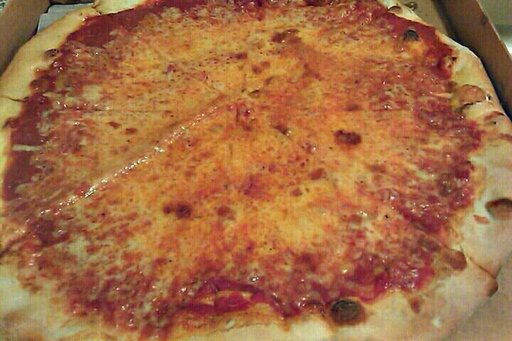

In [28]:
img = Image.open(randpth)
img

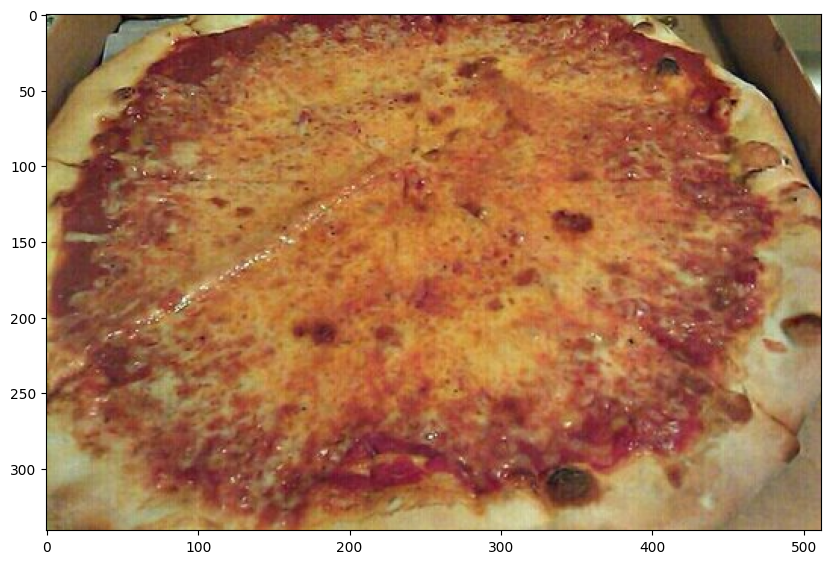

In [29]:
import numpy as np
import matplotlib.pyplot as plt
arr = np.asarray(img)
plt.figure(figsize=(10, 7))
plt.imshow(arr)

In [30]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [31]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4,0.3,0.3,0.1),
    transforms.ToTensor(),
])
test_transforms = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.ToTensor()
])

In [32]:
def plot_transformed_imgs(transform, pths, n=3, seed=42):
    if seed:
        random.seed(seed)
    rpths = random.sample(pths, n)
    for pth in rpths:
        with Image.open(pth) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f'og size {f.size}')
            ax[0].axis(False)
            timg = transform(f)
            timg = timg.permute(1, 2, 0)
            ax[1].imshow(timg)
            ax[1].axis(False)

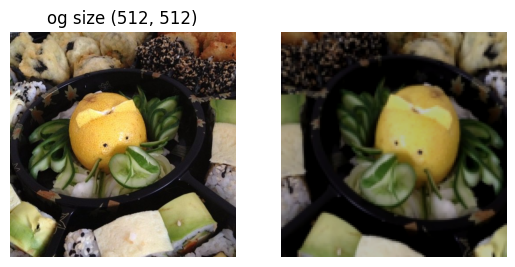

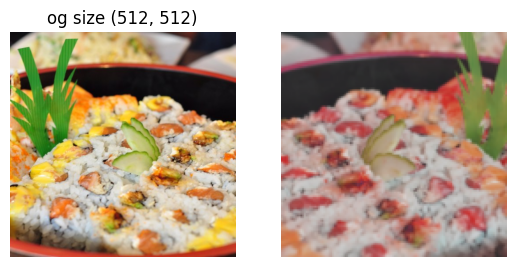

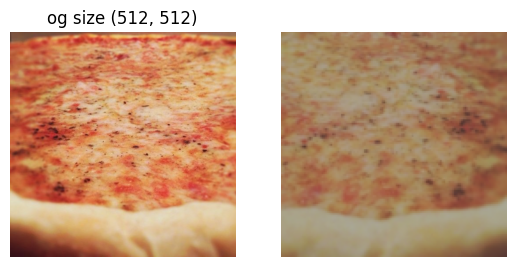

In [33]:
plot_transformed_imgs(train_transforms, img_pth_lst)

In [34]:
train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transforms)

In [35]:
train_dataloader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=10)
test_dataloader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=6)

In [36]:
classes = train_data.classes
classes

['pizza', 'steak', 'sushi']

/tmp/ipykernel_26086/3926548887.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 2)


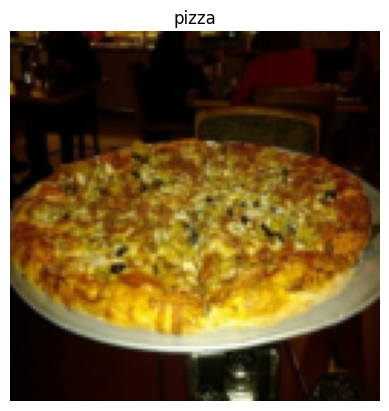

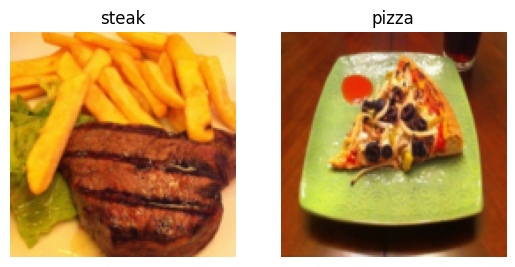

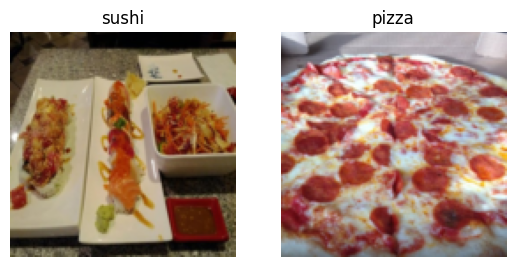

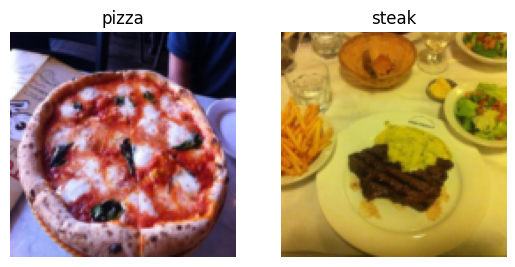

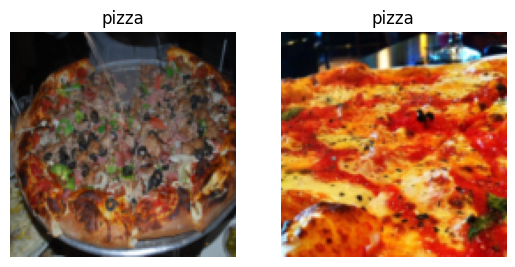

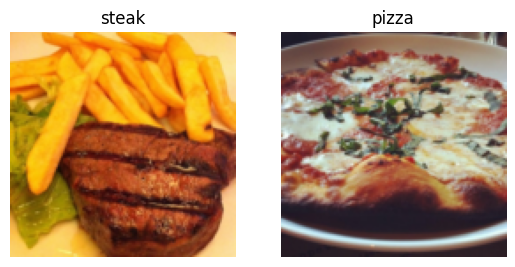

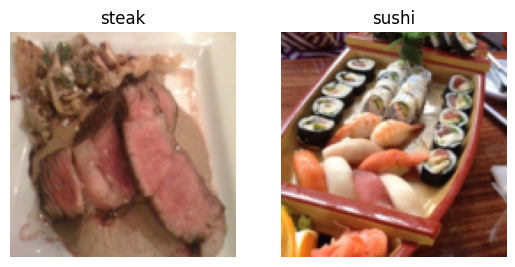

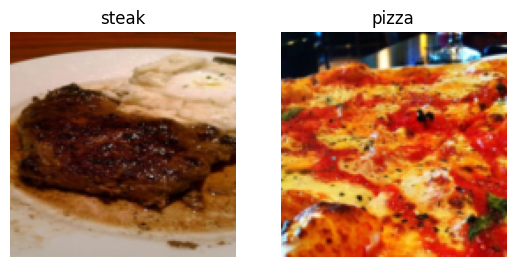

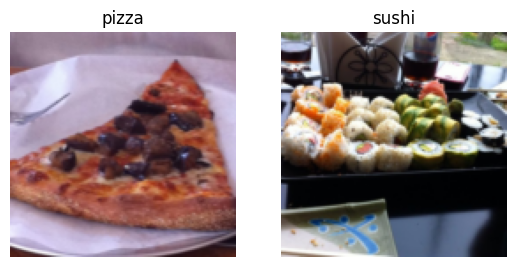

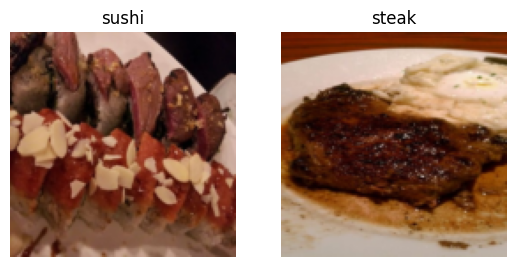

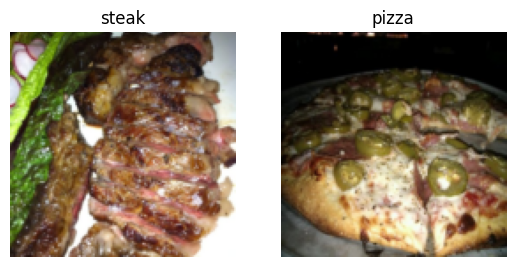

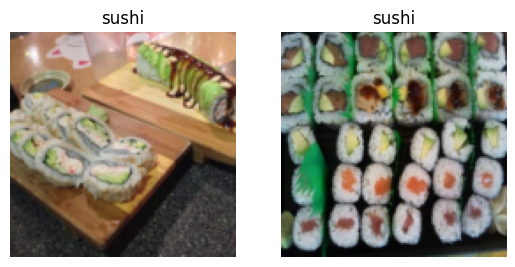

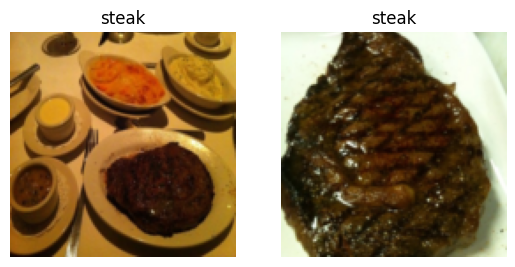

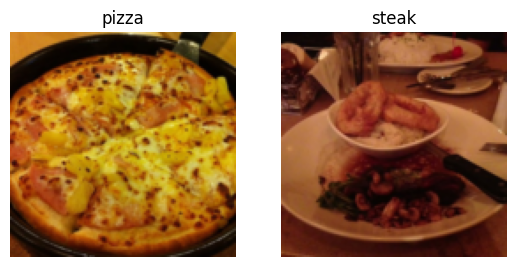

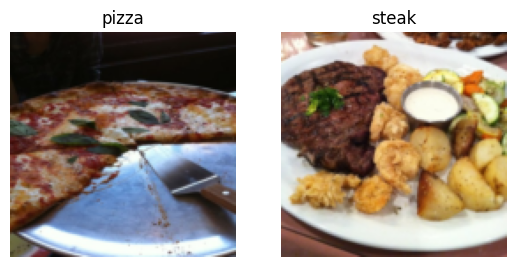

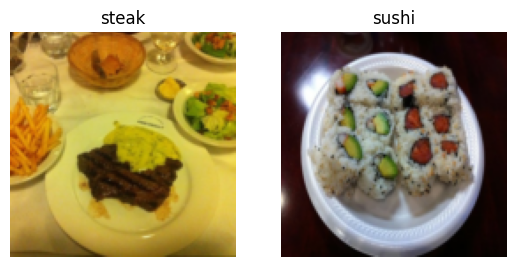

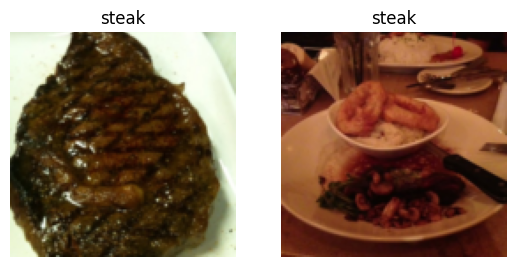

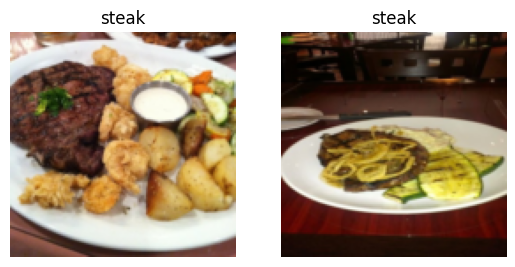

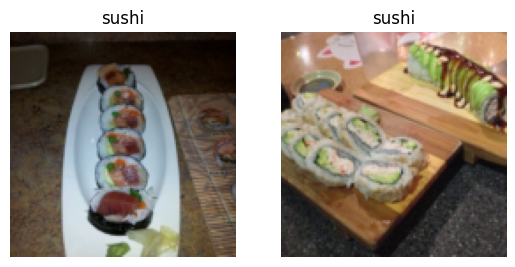

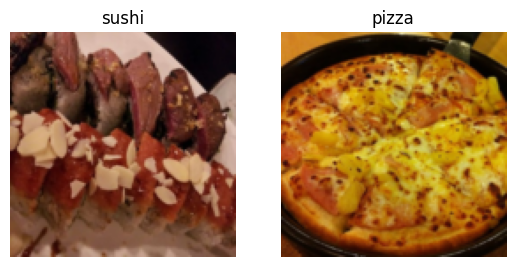

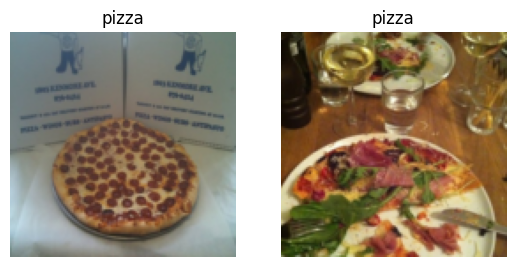

In [37]:
np.random.seed(2)
x, y = next(iter(test_dataloader))
img = x[0].permute(1, 2, 0)
img = img.squeeze()
img = img.numpy()
plt.title(classes[y[0].item()])
plt.imshow(img)
plt.axis('off')
for i in range(20):
    idx1 = np.random.randint(0, 64)
    idx2 = np.random.randint(0, 64)
    img1 = x[idx1].squeeze().permute(1, 2, 0).numpy()
    img2 = x[idx2].squeeze().permute(1, 2, 0).numpy()
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(img1)
    ax[0].set_title(classes[y[idx1].item()])
    ax[0].axis(False)
    ax[1].imshow(img2)
    ax[1].set_title(classes[y[idx2].item()])
    ax[1].axis(False)


In [38]:
import torch
from torch import nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

class CNNfodFlexible(nn.Module):
    def __init__(self, input_channels, hid_units, output_shape):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(input_channels, hid_units, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(hid_units)  # keeps training stable
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(hid_units, hid_units, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hid_units, hid_units, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(hid_units)
        )
        self.dropout = nn.Dropout(0.3)
        self.fc1 = None  # will init dynamically
        self.fc2 = nn.Linear(hid_units, hid_units)
        self.fc3 = nn.Linear(hid_units, output_shape)
    def forward(self, x):
        x = self.conv_block(x)
        x = self.conv_block2(x)
        x = torch.flatten(x, 1)
        
        # init fc1 dynamically first forward
        if self.fc1 is None:
            n_features = x.shape[1]
            self.fc1 = nn.Linear(n_features, self.fc2.in_features).to(x.device)
        
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        x = self.fc3(x)
        return x

model = CNNfodFlexible(3, 192, 3).to(device)


In [39]:
from torch import optim
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(log_dir='runs')
criterion = nn.CrossEntropyLoss()
epochbatch = len(train_dataloader)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
sheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, 50)


In [40]:
# ...existing code...
from torch import optim
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

# create writer once and close after training (not every epoch)
writer = SummaryWriter(log_dir='runs')

epochbatch = len(train_dataloader)


# ...existing code...
def evaluate_model(model, loader, device):
    """Calculates the accuracy of the model on the test/validation set."""
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    accuracy = 100. * correct / total
    return accuracy

def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs, device):
    best_acc = 0.0
    print(f"Starting training on {device}...")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (inputs, targets) in enumerate(train_bar):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # step scheduler per batch if appropriate
            scheduler.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            train_bar.set_postfix({
                'Loss': f'{train_loss/(batch_idx+1):.4f}',
                'Acc': f'{100.*correct/total:.2f}%',
                'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
            })

        # Evaluate on the test set after each epoch
        test_acc = evaluate_model(model, test_loader, device)
        print(f"Test Accuracy after Epoch {epoch+1}: {test_acc:.2f}%")
        writer.add_scalar('Epoch/acc', test_acc, epoch)
        # DO NOT close writer here

        if test_acc > best_acc:
            best_acc = test_acc
            print(f"** New best model saved with accuracy: {best_acc:.2f}% **")
            # save checkpoint if desired

    # close writer after training completes
    writer.close()
    torch.cuda.empty_cache()
    print(f"\nTraining complete. Best Test Accuracy: {best_acc:.2f}%")
# ...existing code...

In [41]:
train_model(model, train_dataloader, test_dataloader, criterion, optimizer, sheduler, 200, device)

Starting training on cuda...


Epoch 1/200: 100%|██████████| 2/2 [00:00<00:00,  2.13it/s, Loss=1.0846, Acc=39.56%, LR=0.000299]


Test Accuracy after Epoch 1: 42.67%
** New best model saved with accuracy: 42.67% **


Epoch 2/200: 100%|██████████| 2/2 [00:00<00:00,  2.25it/s, Loss=1.0555, Acc=46.22%, LR=0.000295]


Test Accuracy after Epoch 2: 41.33%


Epoch 3/200: 100%|██████████| 2/2 [00:00<00:00,  2.27it/s, Loss=0.9920, Acc=59.11%, LR=0.000289]


Test Accuracy after Epoch 3: 44.00%
** New best model saved with accuracy: 44.00% **


Epoch 4/200: 100%|██████████| 2/2 [00:00<00:00,  2.29it/s, Loss=0.9924, Acc=56.89%, LR=0.000281]


KeyboardInterrupt: 

In [ ]:
print(len(train_dataloader))  # how many batches total
print(next(iter(train_dataloader))[0].shape)  # shape of first batch


2
torch.Size([128, 3, 128, 128])


In [ ]:
from model_functions import get_model_results
get_model_results(model, train_dataloader, criterion, device)

{'Loss: ': 0.7903605699539185,
 'accuracy': 69.55138530927834,
 'model': 'CNNfodFlexible'}

In [42]:
# Function to make a prediction on a single image
def predict_single_image(model, image_tensor, device):
    # 1. Ensure the model is in evaluation mode
    model.eval()
    
    # 2. Add a batch dimension and move to the device (GPU)
    # The model expects [Batch, Channel, Height, Width]. 
    # Our image_tensor is currently [1, 28, 28]. We need to add the batch dim.
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    # 3. Disable gradient tracking
    with torch.no_grad():
        # 4. Forward Pass: Get the logits
        output_logits = model(input_tensor)
    
    # 5. Convert logits to class index
    # argmax(dim=1) gets the highest score's index, which is the predicted digit
    predicted_class = output_logits.argmax(dim=1).item()
    
    return predicted_class

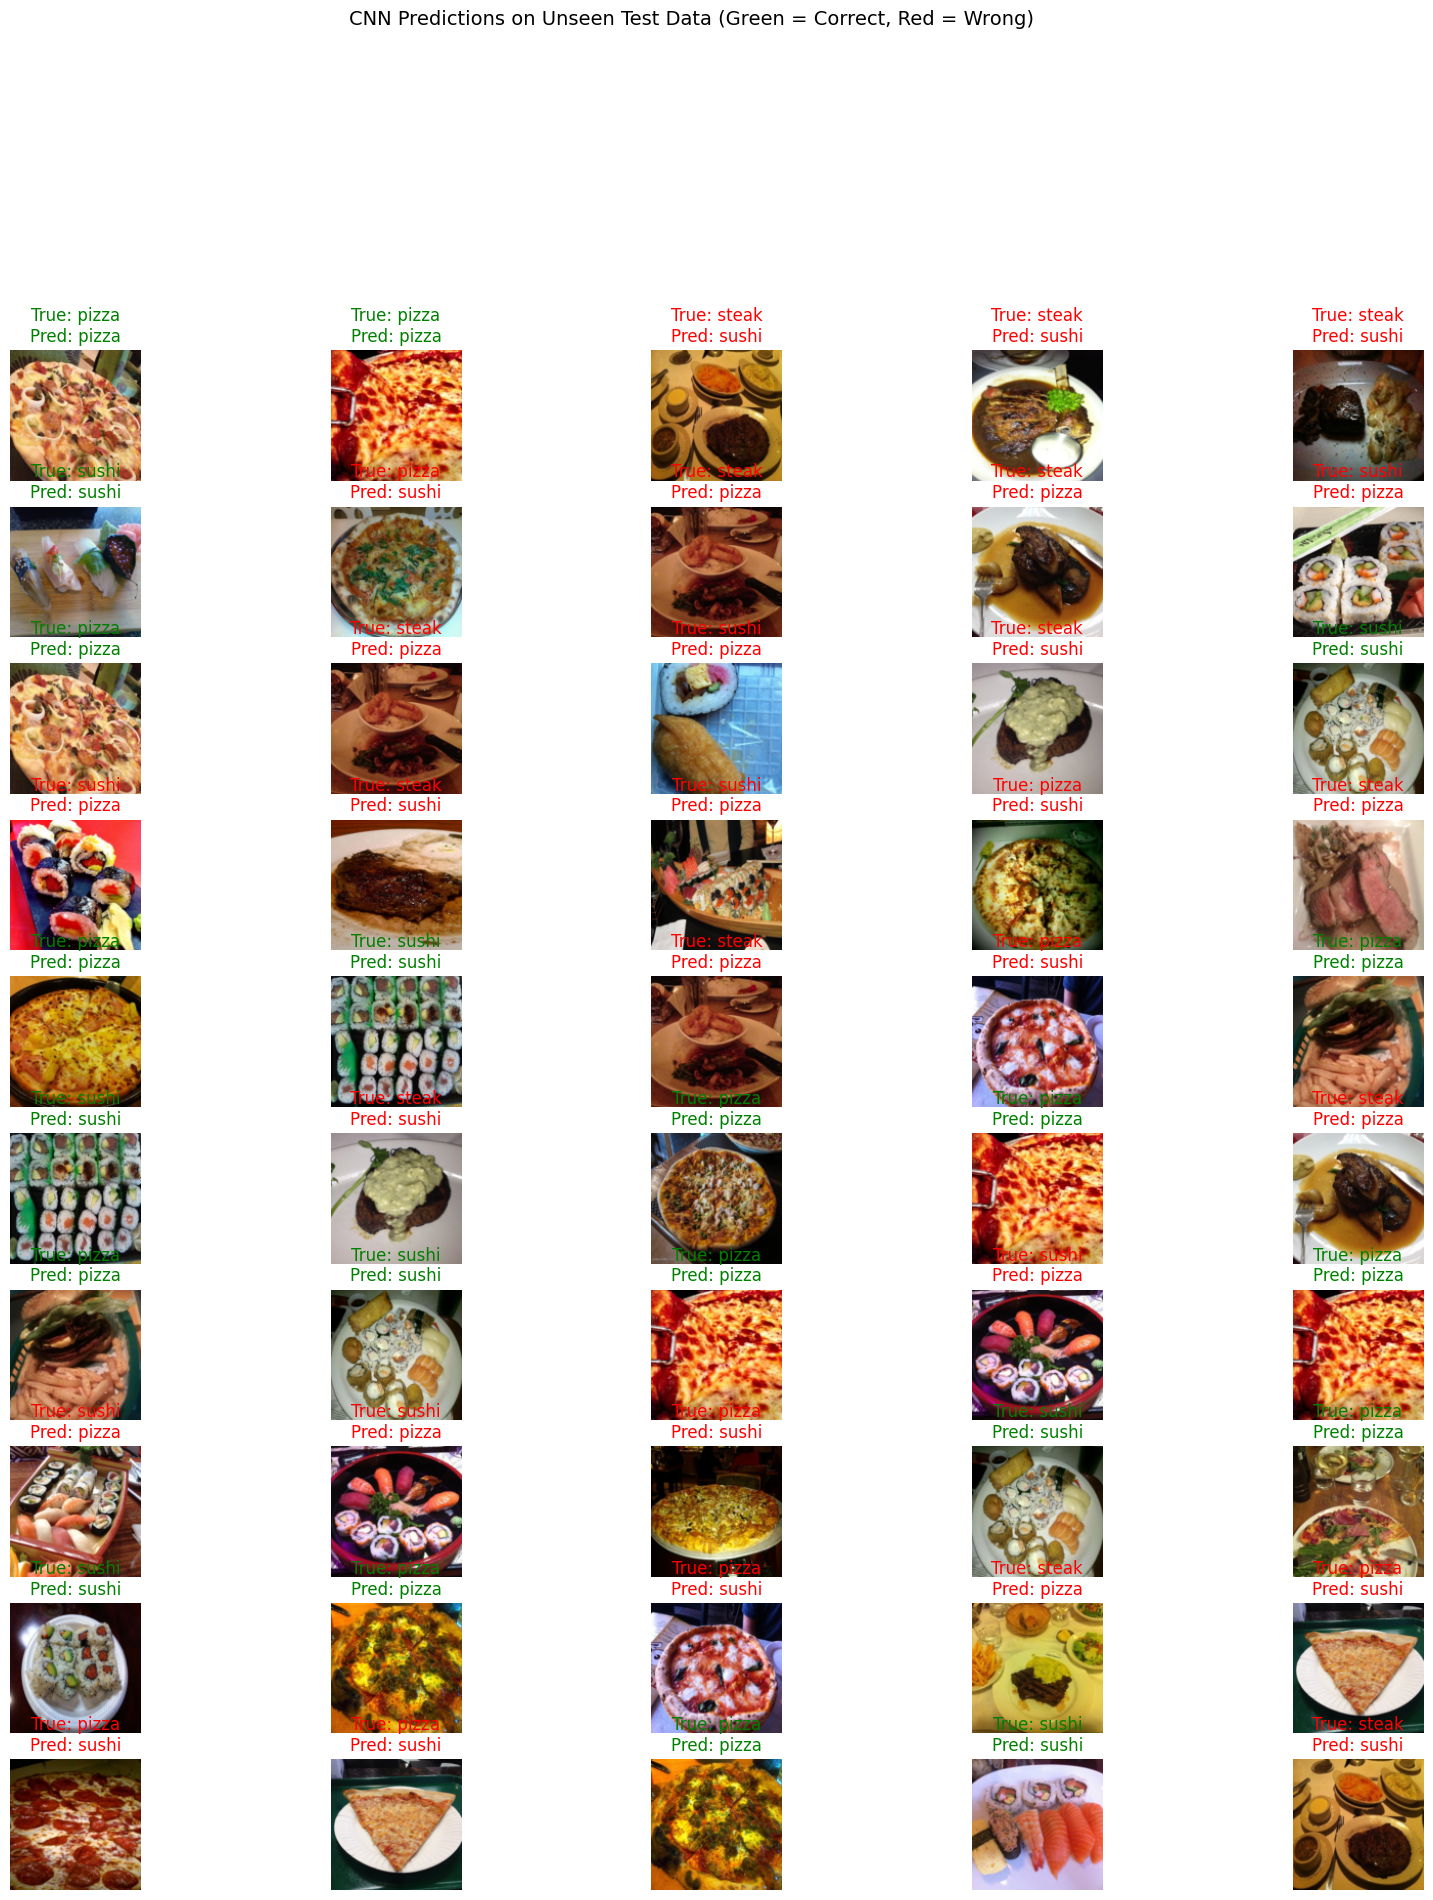

In [44]:
# Grab the first 5 samples from the raw test dataset
import numpy as np
test_samples = []
plotting_dataloader = DataLoader(test_data, 16, True)
for i in range(50):
    # Get the raw tensor and true label from the dataset
    ridx = np.random.randint(0, 16)
    x, y = next(iter(plotting_dataloader))
    image_tensor=x[ridx]
    true_label = y[ridx].item()
    # Get the model's prediction
    predicted_label = predict_single_image(model, image_tensor, device)
    
    # Denormalize the image for display (if you used simple transform, 
    # it's already 0-1 and this is fine)
    image_display = image_tensor.squeeze()
    
    test_samples.append({
        'image': image_display, 
        'true': true_label, 
        'predicted': predicted_label
    })

# Plotting the results
plt.figure(figsize=(20, 20))
for i, sample in enumerate(test_samples):
    ax = plt.subplot(10, 5, i + 1)
    sample['image'] = sample['image'].permute(1, 2, 0)
    plt.imshow(sample['image'], cmap="gray")
    
    color = 'green' if sample['predicted'] == sample['true'] else 'red'
    title = f"True: {classes[sample['true']]}\nPred: {classes[sample['predicted']]}"
    
    plt.title(title, color=color)
    plt.axis("off")

plt.suptitle(
    "CNN Predictions on Unseen Test Data (Green = Correct, Red = Wrong)", 
    y=1.05, 
    fontsize=14
)
plt.show()

In [ ]:
# Change Cell 10 to use the successful path
import os
from torchvision.datasets import ImageFolder

# Use os.path.expanduser to correctly resolve the "~" in PyTorch
test_data = ImageFolder(
    root=os.path.expanduser("~/torch/data/brain_tumors/test"), # <--- CHANGE THIS LINE
    transform=test_transforms
)

In [ ]:
# Check the results immediately after creation
print(f"Classes found: {test_data.classes}")
print(f"Number of images found: {len(test_data)}")

# Check the label distribution
from collections import Counter
targets = [data[1] for data in test_data.samples]
print(f"Class distribution: {Counter(targets)}")

Classes found: ['False', 'True']
Number of images found: 51
Class distribution: Counter({1: 31, 0: 20})
